In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

In [7]:
from src.utils.box import calculate_concept_heights
with open(JSON_PATH, 'r') as f:
    data = json.load(f)
concept_heights = calculate_concept_heights(concept2id, data)

AllenNLP not available. Registrable won't work.


### Train

In [8]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

In [9]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 55 concetti unici e 633 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.6533
Epoca [10/100] | Loss: 0.1968
Epoca [20/100] | Loss: 0.0572
Epoca [30/100] | Loss: 0.0241
Epoca [40/100] | Loss: 0.0125
Epoca [50/100] | Loss: 0.0080
Epoca [60/100] | Loss: 0.0057
Epoca [70/100] | Loss: 0.0048
Epoca [80/100] | Loss: 0.0042
Epoca [90/100] | Loss: 0.0037
Epoca [100/100] | Loss: 0.0035

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: leg | hops
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [10]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

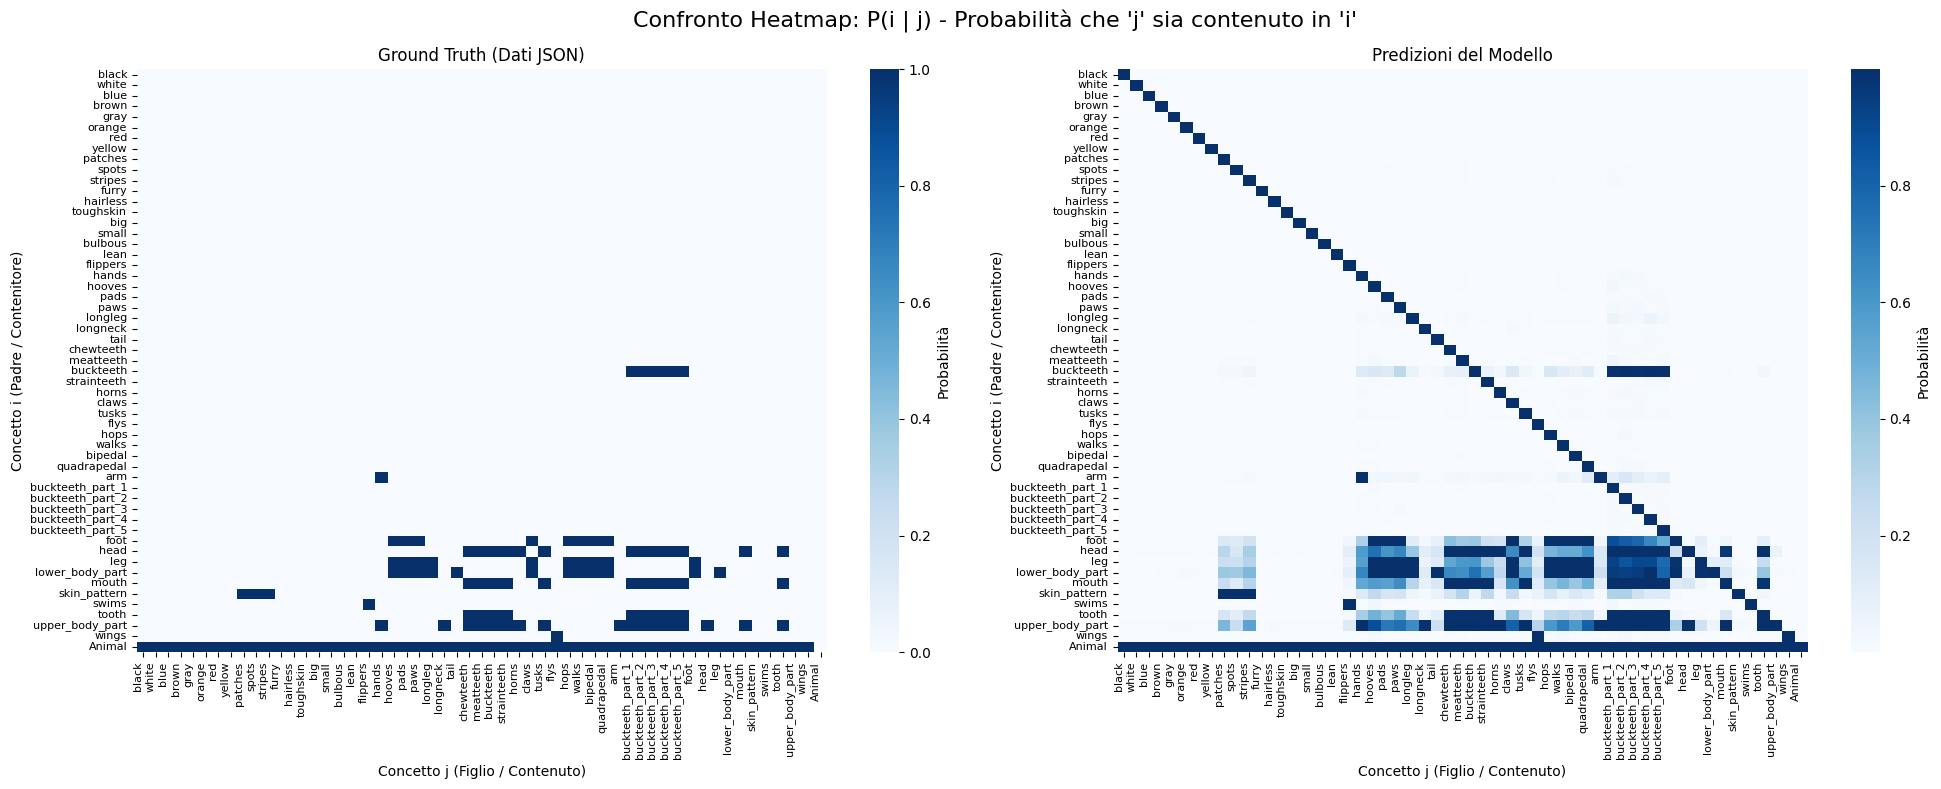

In [11]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

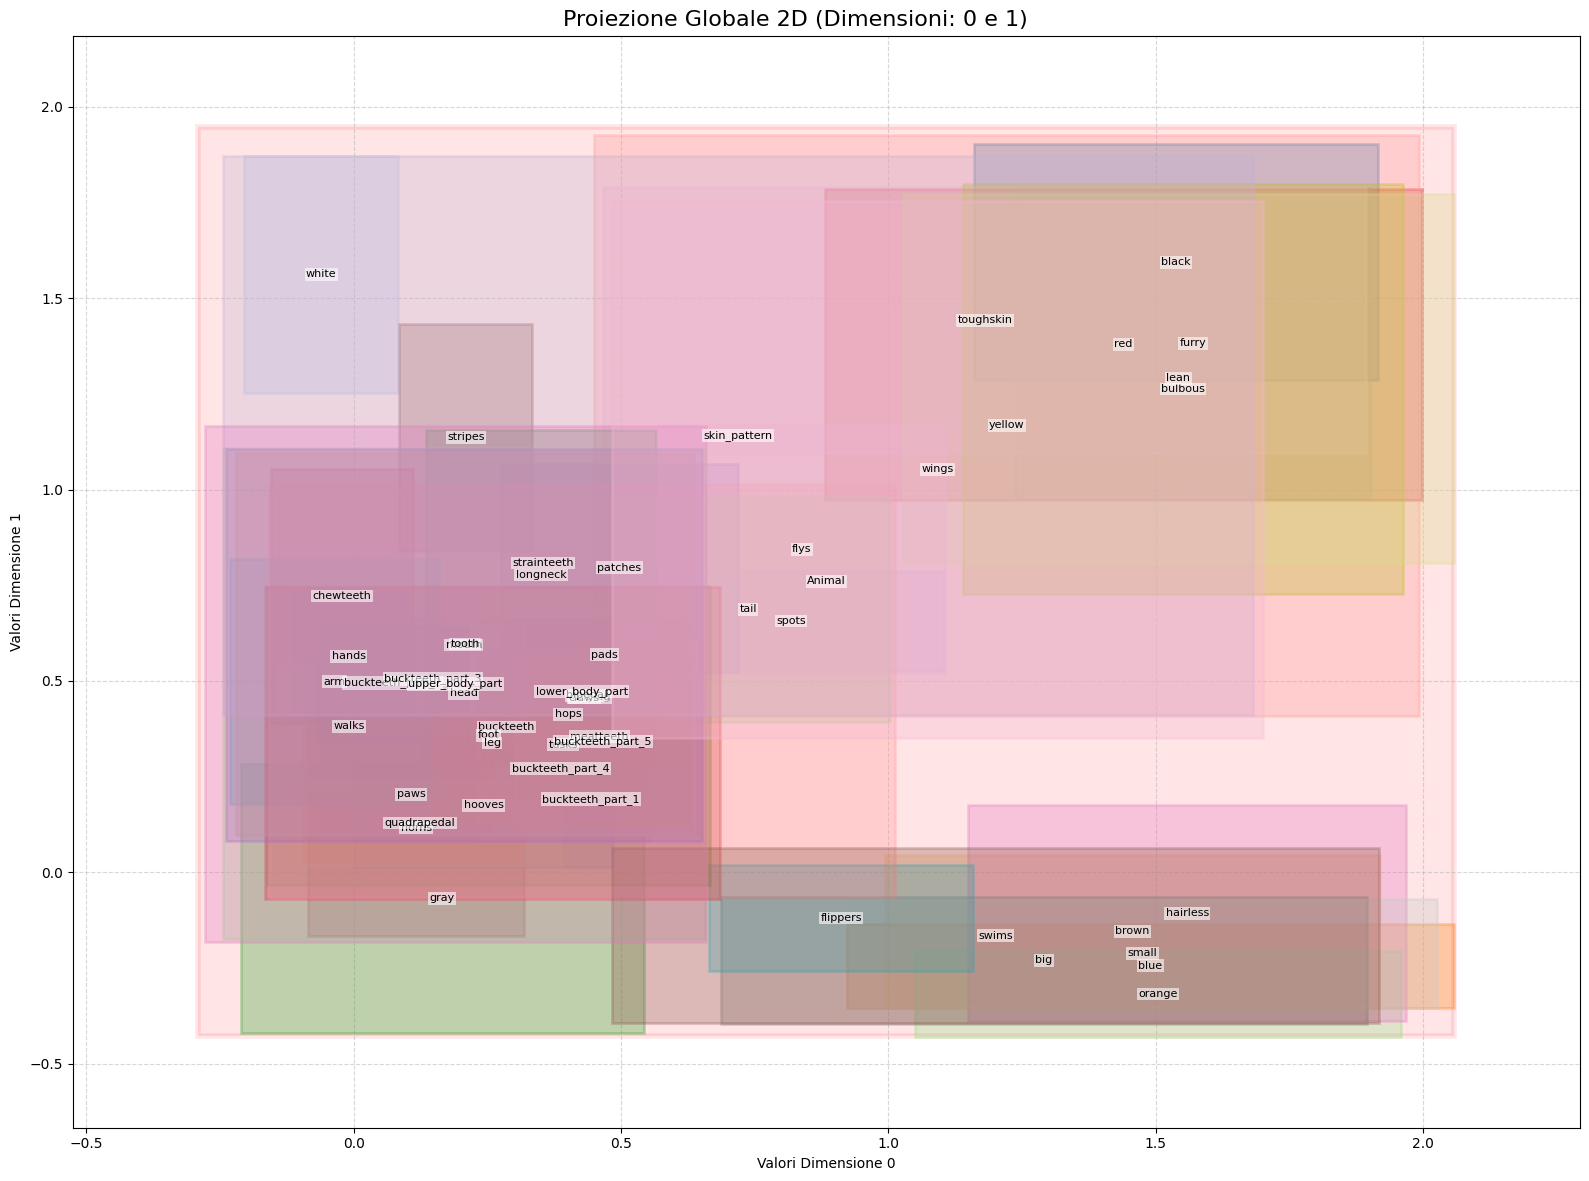

In [12]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

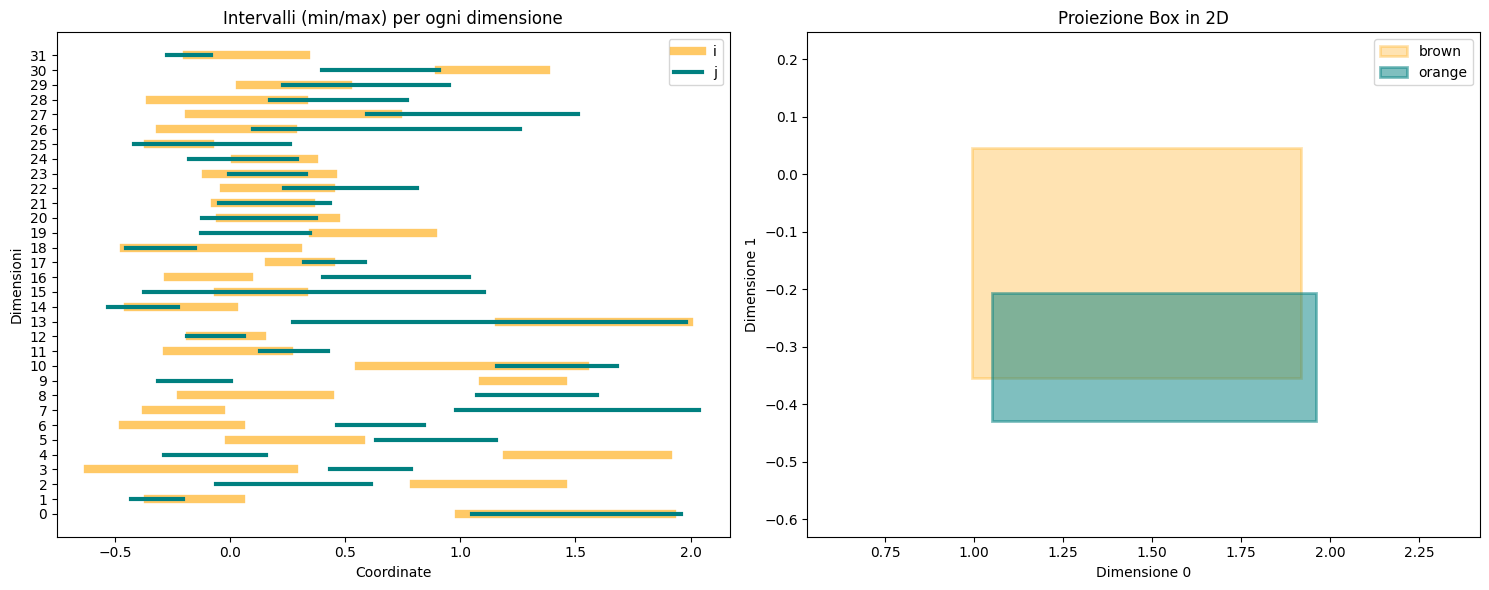

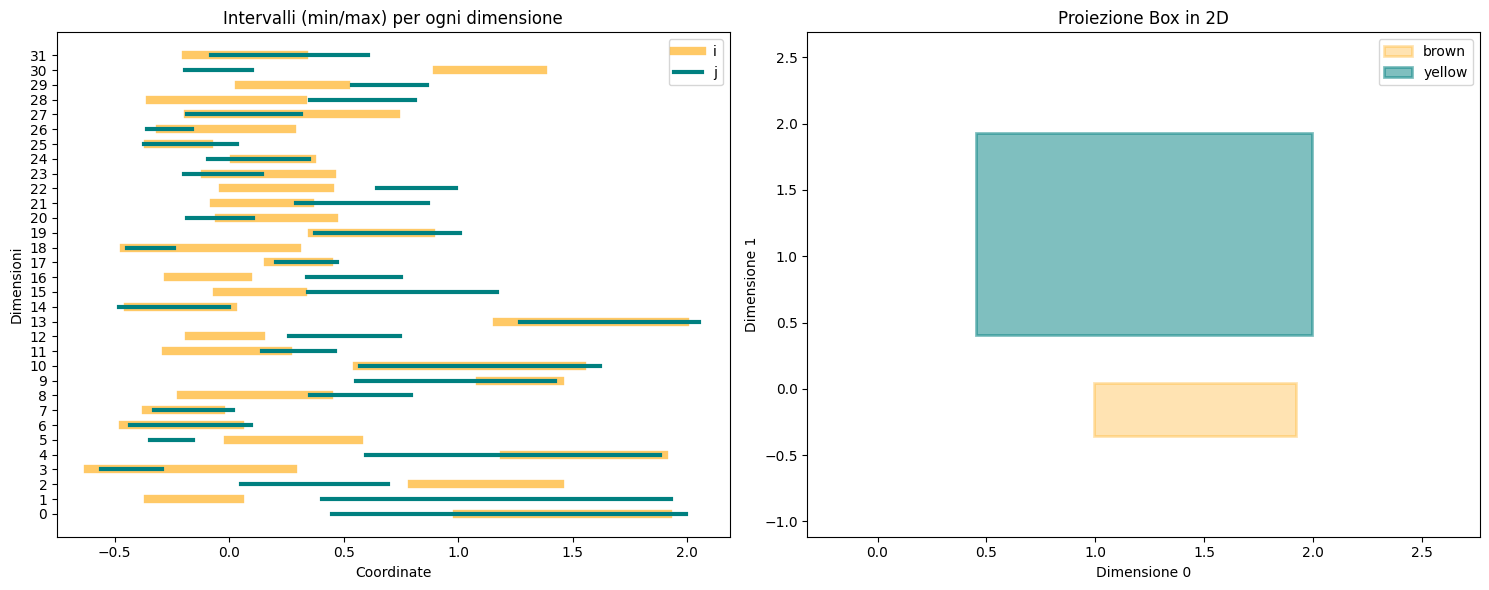

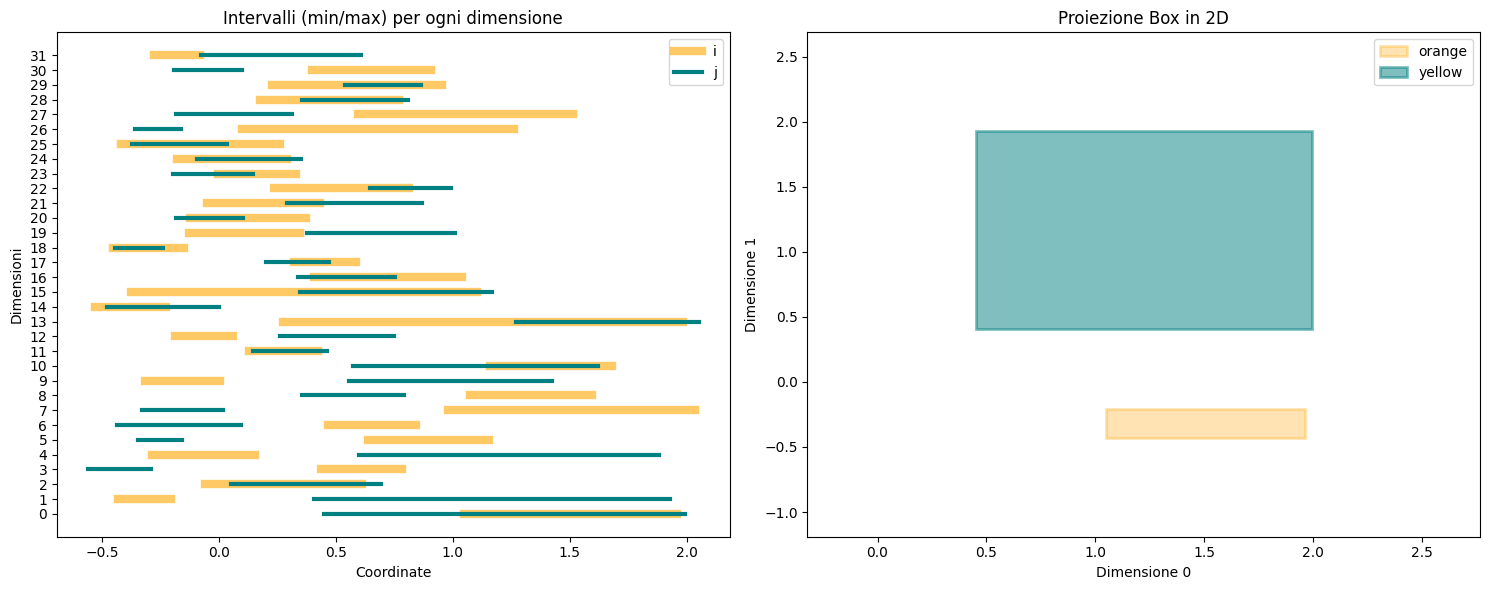

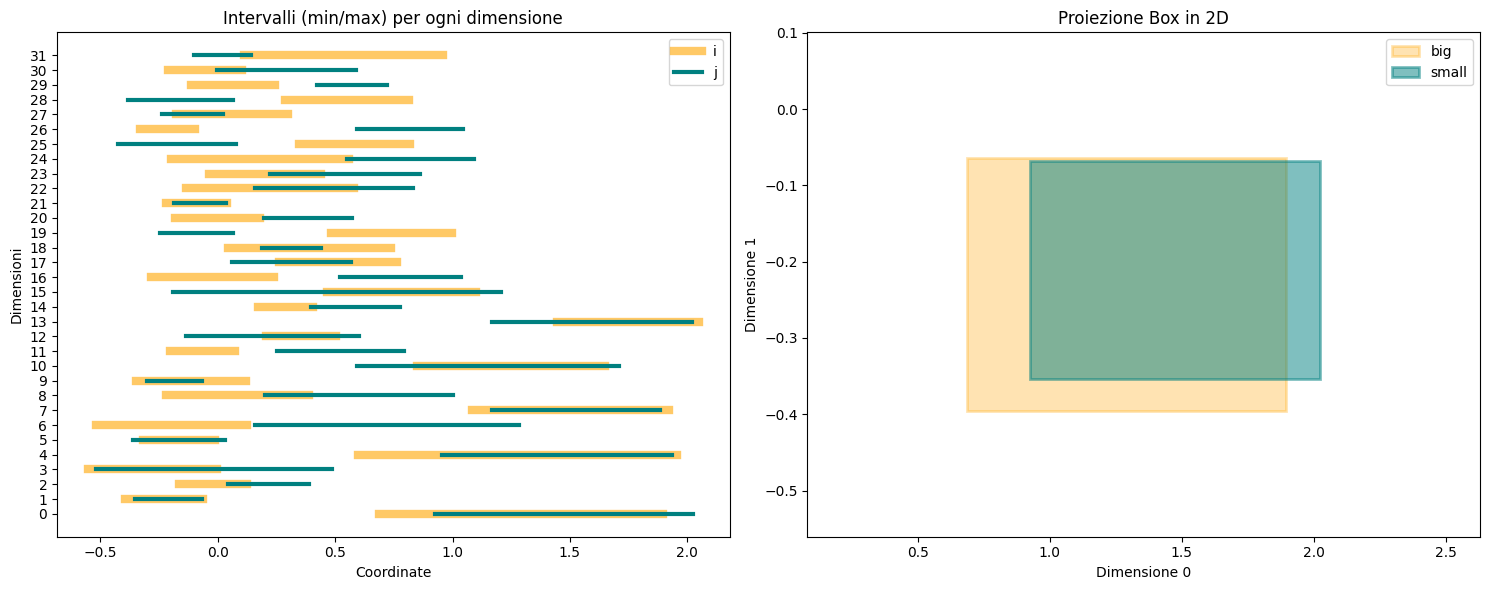

In [13]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [14]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [15]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [16]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [17]:
box_dict = get_box_dict(box_model, id2concept)

In [18]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [19]:
from src.CHM.model import ConceptBottleneckClassifier, ConceptPredictor
from src.CHM.train import joint_training
import matplotlib.pyplot as plt
from src.CHM.test import test_joint_cbm
from src.utils.plot import plot_history, plot_test_results, plot_concept_error_heatmap, plot_concept_uncertainty_heatmap, plot_intervention_curve, analyze_misclassifications_concepts

### CBM with boxes

#### Train

In [20]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)

b_optimizer = torch.optim.Adam(list(b_cls.parameters()) + list(b_concept_predictor.parameters()), lr=0.0005)

lambda_concept = 1.5
gamma_hierarchy = 1

info = "boxes"

b_history = joint_training(
    classifier=b_cls,
    concept_predictor=b_concept_predictor,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    optimizer=b_optimizer,
    criterion_cls=b_cls_criterion,
    concept_heights=concept_heights,
    epochs=7,
    device=device,
    lambda_c=lambda_concept,
    gamma_h=gamma_hierarchy,
    info=info,
    bipolar=False,
)


========== Addestramento Joint CBM (con Logica Gerarchica) ==========
Epoca   1/7 | Acc Train: 78.2% | Acc Val: 89.3%
  TRAIN -> Tot: 1.5706 [Cls: 0.8842 | C: 0.3603 | H: 0.1459]
  VAL   -> Tot: 0.9789 [Cls: 0.3861 | C: 0.3011 | H: 0.1411]

Epoca   2/7 | Acc Train: 91.6% | Acc Val: 89.6%
  TRAIN -> Tot: 0.8542 [Cls: 0.2857 | C: 0.2815 | H: 0.1462]
  VAL   -> Tot: 0.9028 [Cls: 0.3537 | C: 0.2658 | H: 0.1503]

Epoca   3/7 | Acc Train: 93.6% | Acc Val: 89.5%
  TRAIN -> Tot: 0.7453 [Cls: 0.2093 | C: 0.2608 | H: 0.1448]
  VAL   -> Tot: 0.8886 [Cls: 0.3445 | C: 0.2608 | H: 0.1529]

Epoca   4/7 | Acc Train: 94.9% | Acc Val: 90.9%
  TRAIN -> Tot: 0.6791 [Cls: 0.1613 | C: 0.2497 | H: 0.1432]
  VAL   -> Tot: 0.8387 [Cls: 0.3158 | C: 0.2522 | H: 0.1446]

Epoca   5/7 | Acc Train: 96.0% | Acc Val: 90.5%
  TRAIN -> Tot: 0.6369 [Cls: 0.1302 | C: 0.2435 | H: 0.1415]
  VAL   -> Tot: 0.8345 [Cls: 0.3216 | C: 0.2524 | H: 0.1343]

Epoca   6/7 | Acc Train: 96.6% | Acc Val: 91.7%
  TRAIN -> Tot: 0.6036 [Cl

In [ ]:
plot_history(b_history)

#### Test

In [21]:
accuracy, preds, labels, concept_preds, concept_trues, concept_probs = test_joint_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)


Inizio valutazione sul Test Set (Modalità Joint)...
Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.53% (6758/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.93      0.89      0.90       209
           1       0.84      0.96      0.90       170
           2       0.87      0.83      0.85        58
           3       0.63      0.82      0.71        38
           4       0.98      0.98      0.98       110
           5       0.87      0.96      0.91       149
           6       0.95      0.92      0.94       329
           7       0.91      0.91      0.91       207
           8       0.50      0.51      0.51        35
           9       0.91      0.85      0.88       100

   micro avg       0.89      0.91      0.90      1405
   macro avg       0.84      0.86      0.85      1405
weighted avg       0.90      0.91      0.90      1405



In [22]:
from src.CP.test import test_concept_predictor
criterion_cp = nn.BCEWithLogitsLoss()
_, _, _, _, _ =test_concept_predictor(b_concept_predictor, test_dataloader, class_concept_matrix, criterion_cp, device)

Inizio valutazione del Concept Predictor sul Test Set...
--------------------------------------------------
TEST CONCEPT PREDICTOR COMPLETATO
Test Loss: 0.2261
Test Concept Accuracy (Globale): 87.61%
--------------------------------------------------


In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="ox"
)

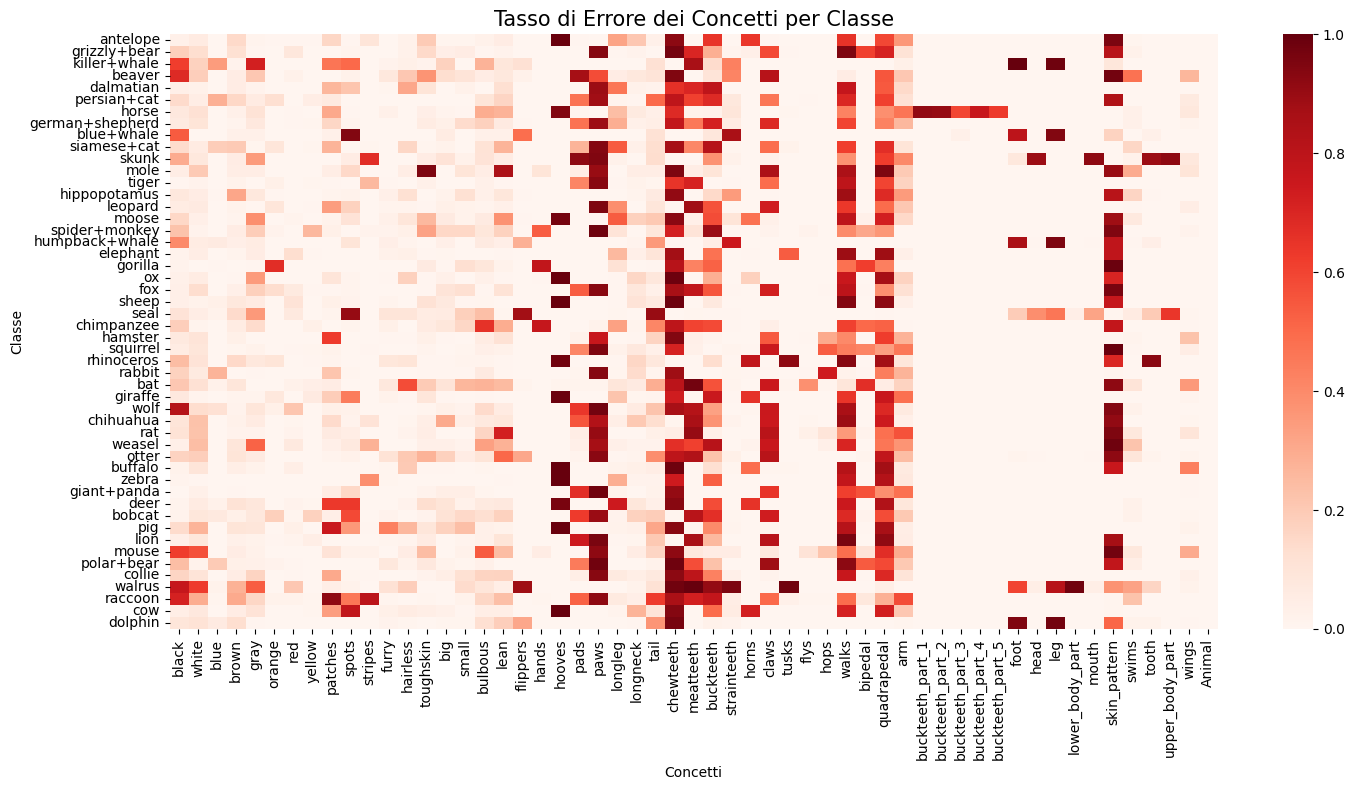

In [24]:
plot_concept_error_heatmap(labels, concept_preds, concept_trues, classes, concepts)

In [ ]:
analyze_misclassifications_concepts(preds, labels, concept_preds, concept_trues, classes, concepts, num_examples=10)

In [ ]:
plot_concept_uncertainty_heatmap(labels, concept_probs, class_names=classes, concept_names=concepts)

In [23]:
from src.utils.box import compute_stratified_concept_accuracy
stratified_acc = compute_stratified_concept_accuracy(concept_preds, concept_trues, concept_heights, id2concept)


 ACCURATEZZA CONCETTI STRATIFICATA PER ALTEZZA

► Livello  6 (Padri/Radici) | N. Concetti: 1 | Acc. Media: 100.00%
------------------------------------------------------------
    Animal                    : 100.00% 

► Livello  5 (Intermedio) | N. Concetti: 1 | Acc. Media: 97.84%
------------------------------------------------------------
    upper_body_part           :  97.84% 

► Livello  4 (Intermedio) | N. Concetti: 1 | Acc. Media: 98.47%
------------------------------------------------------------
    head                      :  98.47% 

► Livello  3 (Intermedio) | N. Concetti: 2 | Acc. Media: 98.98%
------------------------------------------------------------
    mouth                     :  98.63% 
    lower_body_part           :  99.33% 

► Livello  2 (Intermedio) | N. Concetti: 2 | Acc. Media: 94.92%
------------------------------------------------------------
    leg                       :  92.82% 
    tooth                     :  97.03% 

► Livello  1 (Intermedio) | N. 

In [ ]:
_, _, _, _, _, _ = test_joint_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
    logical_smoothing=True
)

### CBM with cond prob distrib

#### Train

In [ ]:
info = "rel_matrix"
bipolar = True
cp_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
cp_criterion = nn.CrossEntropyLoss()

cp_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
cp_optimizer = torch.optim.Adam(list(cp_cls.parameters()) + list(cp_concept_predictor.parameters()), lr=0.001)

cp_cls_history = joint_training(
    cp_cls,
    cp_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    cp_optimizer,
    cp_criterion,
    concept_heights,
    EPOCHS, 
    device,
    lambda_concept,
    gamma_hierarchy,
    info,
    bipolar=False,
)

In [ ]:
plot_history(cp_cls_history)

#### Test

In [ ]:
cp_accuracy, cp_preds, cp_labels = test_joint_cbm(
    cp_cls,
    cp_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=cp_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM standard

In [ ]:
info = "concepts"
c_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
c_criterion = nn.CrossEntropyLoss()


c_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
c_optimizer = torch.optim.Adam(list(c_cls.parameters()) + list(c_concept_predictor.parameters()), lr=0.001)

c_cls_history = joint_training(
    c_cls,
    c_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    c_optimizer,
    c_criterion,
    concept_heights,
    EPOCHS, 
    device,
    lambda_concept,
    gamma_hierarchy,
    info,
    bipolar=False,
)

In [ ]:
from src.utils.plot import plot_history
plot_history(c_cls_history)

In [ ]:
c_accuracy, c_preds, c_labels = test_joint_cbm(
    c_cls,
    c_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    c_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=c_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)